In [1]:
import sys
sys.path.insert(0, '..')

In [14]:
import utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import bootstrap as scipy_bootstrap

## Cargar datos

In [3]:
clusters = pd.read_csv('./../data/processed/largest_clusters.csv')
members = pd.read_csv('./../data/processed/largest_clusters_members.csv')

In [6]:
mask_rv = members['RV'].notna()
members_rv = members[mask_rv].copy()

In [10]:
cluster_name = 'King_11'
cluster = clusters[clusters['Name'] == cluster_name]
cluster_members = members[members['Name'] == cluster_name]
cluster_members_rv = members_rv[members_rv['Name'] == cluster_name]

In [11]:
print(f"Miembros totales      : {len(cluster_members)}")
print(f"Con velocidad radial  : {len(cluster_members_rv)}  ({100*len(cluster_members_rv)/len(cluster_members):.1f}%)")

Miembros totales      : 1056
Con velocidad radial  : 78  (7.4%)


In [15]:
ra0 = float(cluster['RA_ICRS'].values[0])  # grados
dec0 = float(cluster['DE_ICRS'].values[0]) # grados
d0 = float(cluster['dist50'].values[0])    # pc

In [19]:
ras = cluster_members_rv['RA_ICRS'].values  # grados
decs = cluster_members_rv['DE_ICRS'].values # grados

In [20]:
X, Y = utils.tangent_plane_projection(ras, decs, ra0, dec0, d0)

In [22]:
Rs = np.sqrt(X**2 + Y**2)
cluster_members_rv['R'] = Rs

In [25]:
N_rv = len(cluster_members_rv)
n_bins = max(3, int(np.sqrt(N_rv))) # regla de N**0.5 y mínimo 3 bins
min_stars = 3                       # umbral de calidad

In [28]:
percentiles = np.linspace(0, 100, n_bins + 1)
edges = np.percentile(cluster_members_rv["R"], percentiles)
edges[0] -= 1e-6 # incluir el radio mínimo exacto
edges[-1] += 1e-6

In [29]:
print(f"\nNúmero de bins        : {n_bins}")
print(f"Bordes de bins (pc)   : {np.round(edges, 3)}")


Número de bins        : 8
Bordes de bins (pc)   : [ 0.448  1.115  2.03   2.597  3.323  3.997  5.145  8.398 32.135]


In [30]:
results = []

for i in range(n_bins):
    R_lo, R_hi = edges[i], edges[i + 1]
    R_mid = 0.5 * (R_lo + R_hi)

    # Estrellas del bin con RV válida
    in_bin = cluster_members_rv[(cluster_members_rv["R"] >= R_lo) & (cluster_members_rv["R"] < R_hi)]
    n = len(in_bin)
    vr = in_bin["RV"].values

    if n < min_stars:
        # Bin descartado: insuficientes datos
        results.append({
            "R_mid": R_mid, "R_lo": R_lo, "R_hi": R_hi,
            "sigma": np.nan, "sigma_err": np.nan, "n": n
        })
        continue

    # Varianza con corrección de Bessel (divisor n-1)
    v_mean = np.mean(vr)
    sigma2 = np.sum((vr - v_mean) ** 2) / (n - 1)
    sigma  = np.sqrt(sigma2)

    # Error en σ vía bootstrap (percentil 16–84 ≈ ±1σ)
    def sigma_statistic(v, axis=-1):
        return np.std(v, ddof=1, axis=axis)

    boot = scipy_bootstrap(
        (vr,),
        sigma_statistic,
        n_resamples=2000,
        confidence_level=0.68,   # ±1σ equivalente
        method="percentile",
        random_state=42
    )
    sigma_lo = sigma - boot.confidence_interval.low
    sigma_hi = boot.confidence_interval.high - sigma
    sigma_err = 0.5 * (sigma_lo + sigma_hi)  # error simétrico aproximado

    results.append({
        "R_mid": R_mid, "R_lo": R_lo, "R_hi": R_hi,
        "sigma": sigma, "sigma_err": sigma_err, "n": n
    })

In [31]:
df_res = pd.DataFrame(results)
valid  = df_res["sigma"].notna()

In [33]:
print("\nResultados por bin:")
print(df_res[["R_mid", "n", "sigma", "sigma_err"]].to_string(index=False))


Resultados por bin:
    R_mid  n     sigma  sigma_err
 0.781394 10  6.844953   3.003025
 1.572447 10  5.357488   2.367218
 2.313515  9  4.857543   1.053926
 2.959916 10  3.663764   1.092238
 3.659762 10 28.217220  17.875984
 4.570669  9 20.485107  11.568873
 6.771471 10  4.829691   2.025615
20.266629 10 17.421767   3.602255


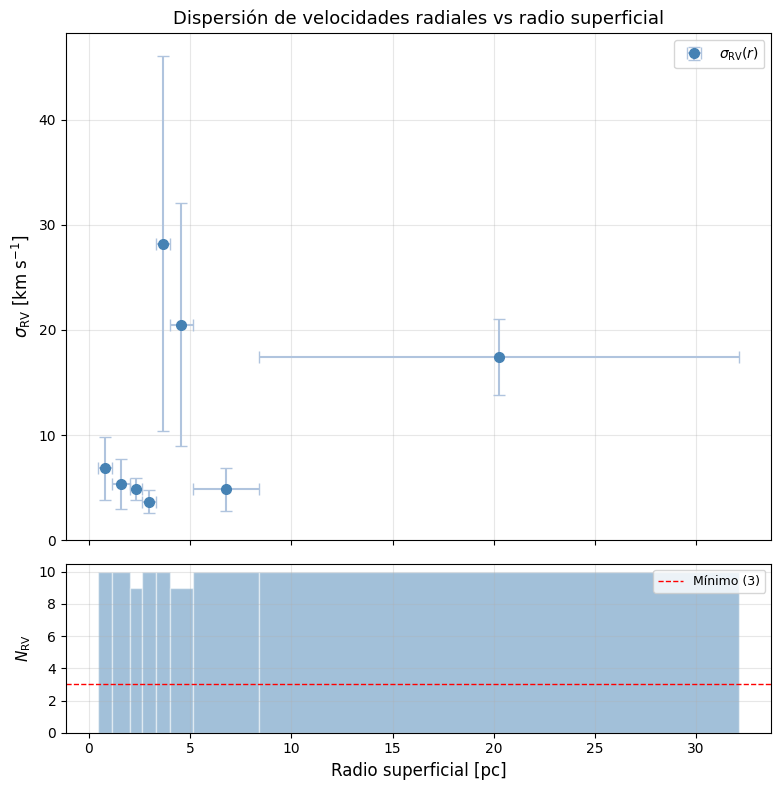

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8),
                         gridspec_kw={"height_ratios": [3, 1]},
                         sharex=True)

ax = axes[0]
ax.errorbar(
    df_res.loc[valid, "R_mid"],
    df_res.loc[valid, "sigma"],
    yerr=df_res.loc[valid, "sigma_err"],
    xerr=[
        df_res.loc[valid, "R_mid"] - df_res.loc[valid, "R_lo"],
        df_res.loc[valid, "R_hi"] - df_res.loc[valid, "R_mid"],
    ],
    fmt="o", color="steelblue", ecolor="lightsteelblue",
    elinewidth=1.5, capsize=4, markersize=7,
    label=r"$\sigma_\mathrm{RV}(r)$"
)

# Bins descartados (pocos datos)
invalid = df_res[~valid]
if len(invalid) > 0:
    ax.scatter(invalid["R_mid"], [0.5]*len(invalid),
               marker="x", color="gray", s=50,
               label=f"Bin descartado (n < {min_stars})")

ax.set_ylabel(r"$\sigma_\mathrm{RV}$ [km s$^{-1}$]", fontsize=12)
ax.set_title("Dispersión de velocidades radiales vs radio superficial", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# Panel inferior: número de estrellas con RV por bin
ax2 = axes[1]
ax2.bar(df_res.loc[valid, "R_mid"], df_res.loc[valid, "n"],
        width=df_res.loc[valid, "R_hi"] - df_res.loc[valid, "R_lo"],
        color="steelblue", alpha=0.5, align="center", edgecolor="white")
ax2.axhline(min_stars, color="red", linestyle="--",
            linewidth=1, label=f"Mínimo ({min_stars})")
ax2.set_xlabel("Radio superficial [pc]", fontsize=12)
ax2.set_ylabel("$N_\\mathrm{RV}$", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("sigma_vs_r.pdf", dpi=150, bbox_inches="tight")
plt.show()